# Optimal Openings Analysis by Elo Range
This study analyzes a dataset of 6 million chess games to identify the most successful openings across different Elo levels.

**Analysis Objectives:**
* Categorize players into Elo groups (Noob, Intermediate, Advanced, Expert).
* Filter for statistical significance (minimum 100 games per opening).
* Visualize win rates for both White and Black perspectives.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import gc

%matplotlib inline

# Helper function to wrap long opening names for better visualization
def wrap_labels(labels, width=20):
    return [textwrap.fill(label, width) for label in labels]

## Data Exploratory Analysis (EDA)
Checking the file path and inspecting the first 5 rows to understand the dataset structure and column headers.

In [2]:
# Adjust the path according to your folder structure
file_path = "../../chess_games.csv"

df_preview = pd.read_csv(file_path, nrows=5)
pd.set_option('display.max_columns', None)

print("First 5 rows of the dataset:")
display(df_preview)

print("\nDataset Information:")
df_preview.info()

First 5 rows of the dataset:


,Event,White,Black,Result,UTCDate,UTCTime,WhiteElo,BlackElo,WhiteRatingDiff,BlackRatingDiff,ECO,Opening,TimeControl,Termination,AN
0,Classical,eisaaaa,HAMID449,1-0,2016.06.30,22:00:01,1901,1896,11.0,-11.0,D10,Slav Defense,300+5,Time forfeit,1. d4 d5 2. c4 c6 3. e3 a6 4. Nf3 e5 5. cxd5 e...
1,Blitz,go4jas,Sergei1973,0-1,2016.06.30,22:00:01,1641,1627,-11.0,12.0,C20,King's Pawn Opening: 2.b3,300+0,Normal,1. e4 e5 2. b3 Nf6 3. Bb2 Nc6 4. Nf3 d6 5. d3 ...
2,Blitz tournament,Evangelistaizac,kafune,1-0,2016.06.30,22:00:02,1647,1688,13.0,-13.0,B01,Scandinavian Defense: Mieses-Kotroc Variation,180+0,Time forfeit,1. e4 d5 2. exd5 Qxd5 3. Nf3 Bg4 4. Be2 Nf6 5....
3,Correspondence,Jvayne,Wsjvayne,1-0,2016.06.30,22:00:02,1706,1317,27.0,-25.0,A00,Van't Kruijs Opening,-,Normal,1. e3 Nf6 2. Bc4 d6 3. e4 e6 4. Nf3 Nxe4 5. Nd...
4,Blitz tournament,kyoday,BrettDale,0-1,2016.06.30,22:00:02,1945,1900,-14.0,13.0,B90,"Sicilian Defense: Najdorf, Lipnitsky Attack",180+0,Time forfeit,1. e4 c5 2. Nf3 d6 3. d4 cxd4 4. Nxd4 Nf6 5. N...



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Event            5 non-null      str    
 1   White            5 non-null      str    
 2   Black            5 non-null      str    
 3   Result           5 non-null      str    
 4   UTCDate          5 non-null      str    
 5   UTCTime          5 non-null      str    
 6   WhiteElo         5 non-null      int64  
 7   BlackElo         5 non-null      int64  
 8   WhiteRatingDiff  5 non-null      float64
 9   BlackRatingDiff  5 non-null      float64
 10  ECO              5 non-null      str    
 11  Opening          5 non-null      str    
 12  TimeControl      5 non-null      str    
 13  Termination      5 non-null      str    
 14  AN               5 non-null      str    
dtypes: float64(2), int64(2), str(11)
memory usage: 732.0 bytes


## Main Analysis Code
In this section, we process the large dataset in chunks to calculate win rates based on a specific Elo group provided by the user.

In [3]:
user_elo = int(input("Enter Elo for Analysis: "))

all_results = []
elos = [0, 1200, 1600, 2000, np.inf]
labels_list = ['Noob', 'Intermediate', 'Advanced', 'Expert']
ranges = ['0-1200', '1200-1600', '1600-2000', '2000+']

print("Processing data chunks...")

# Efficiently reading the dataset in chunks to manage memory
chunks = pd.read_csv(file_path, usecols=["Opening", "WhiteElo", "BlackElo", "Result"], chunksize=500000)

for chunk in chunks:
    # Calculate Average Elo and assign Group
    chunk['AvgElo'] = (chunk['WhiteElo'] + chunk['BlackElo']) / 2
    chunk['Elo_Group'] = pd.cut(chunk['AvgElo'], bins=elos, labels=labels_list)
    
    # Map results to numerical scores (White win = 1, Draw = 0.5, Black win = 0)
    res_map = {'1-0': 1, '0-1': 0, '1/2-1/2': 0.5}
    chunk['Score'] = chunk['Result'].map(res_map)
    
    # Extract cleaned data
    processed_chunk = chunk[['Opening', 'Elo_Group', 'Score']].dropna()
    all_results.append(processed_chunk)
    
    # Clear memory
    del chunk
    gc.collect()

df_final = pd.concat(all_results)
print("Data aggregation completed!")

Processing data chunks...
Data aggregation completed!


## Filtering and Ranking
Identifying the target Elo group and filtering for openings with at least 100 games played to ensure reliability.

In [4]:
# Determine target group based on user input
if user_elo < 1200:
    target_group, target_range = 'Noob', ranges[0]
elif user_elo < 1600:
    target_group, target_range = 'Intermediate', ranges[1]
elif user_elo < 2000:
    target_group, target_range = 'Advanced', ranges[2]
else:
    target_group, target_range = 'Expert', ranges[3]

# Filter for the specific Elo group
user_level_data = df_final[df_final['Elo_Group'] == target_group]

# Filter for reliability: Minimum 100 games played
counts = user_level_data.groupby('Opening')['Score'].count()
reliable_openings = counts[counts > 100].index
filtered_data = user_level_data[user_level_data['Opening'].isin(reliable_openings)]

# Calculate final averages for Top 5
recommendations = filtered_data.groupby('Opening')['Score'].mean()
white_best = recommendations.sort_values(ascending=False).head(5)
black_best = recommendations.sort_values(ascending=True).head(5)

print(f"Top openings found for {target_group} level.")

Top openings found for Intermediate level.


## Data Visualization
Comparing the top 5 openings for White and the top 5 defenses for Black.

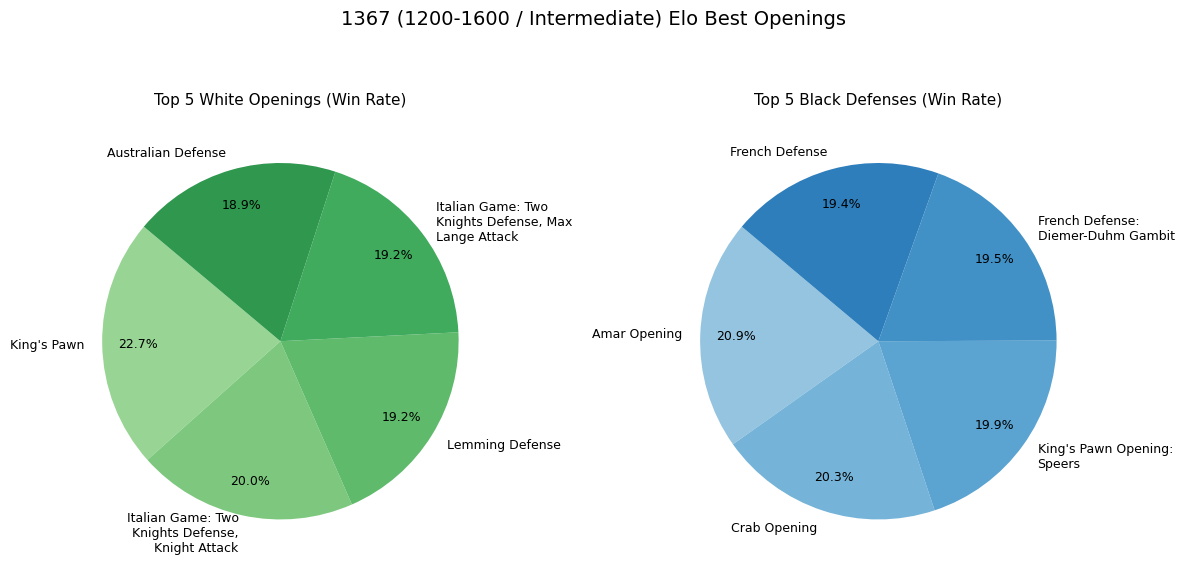

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle(f"{user_elo} ({target_range} / {target_group}) Elo Best Openings", fontsize=14, y=1.02)

# Visualization for White
ax1.pie(white_best, 
        labels=wrap_labels(white_best.index), 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=plt.cm.Greens(np.linspace(0.4, 0.7, 5)),
        textprops={'fontsize': 9},
        pctdistance=0.8)
ax1.set_title("Top 5 White Openings (Win Rate)", fontsize=11, pad=10)

# Visualization for Black
black_win_rate = 1 - black_best
ax2.pie(black_win_rate, 
        labels=wrap_labels(black_best.index), 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=plt.cm.Blues(np.linspace(0.4, 0.7, 5)),
        textprops={'fontsize': 9},
        pctdistance=0.8)
ax2.set_title("Top 5 Black Defenses (Win Rate)", fontsize=11, pad=10)

plt.tight_layout()
plt.show()